In [1]:
# !rm -rf cache/validation/

In [2]:
import os
from multiprocess import set_start_method
set_start_method("spawn")
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)

In [ ]:


from coreset_trainer.trainer import CoresetTrainer
import os
import torch

import argparse



In [ ]:
from load_experiment_data import (
    train_dataset_name,
    test_dataset_name,
    train_dataset_split,
    test_dataset_split,
    load_data_and_estimators,
    explanation_types,
    linear_coders,
    explanation_seed,
    explanation_k
)
# train_dataset, test_dataset, estimators = load_data_and_estimators()


In [ ]:
from functools import partial
from explanations import KRandom
k_random_types = [partial(KRandom, seed=s) for s in range(9)]
explanation_types = explanation_types + k_random_types

In [ ]:
import logging
from concurrent.futures import ProcessPoolExecutor, as_completed
import torch
import multiprocessing
from tqdm import tqdm
import itertools
import pandas as pd
import traceback

logging.basicConfig(level=logging.ERROR, format='%(asctime)s [%(levelname)s] %(message)s')
multiprocessing.set_start_method('spawn', force=True)
torch.manual_seed(42)




num_devices = torch.cuda.device_count()







In [ ]:
# import dask.dataframe as dd
# from dask.distributed import Client, LocalCluster


# cluster = LocalCluster(
#     n_workers=32,              
#     threads_per_worker=2,     
#     memory_limit='8.75GB',     
# )
# client = Client(cluster)
# client

In [ ]:

# device_ids = itertools.cycle(range(num_devices))
# results = []

# from peft import LoraConfig, get_peft_model, PeftModel


# for estimator in estimators:
    

#     explanations = [
#         explanation_type(row.name, estimator)
#         for explanation_type in explanation_types
#         for _, row in estimator.influence_estimate.iloc[test_indices].iterrows()
#     ]
            
        
#     partial_results_dir =  os.path.join("./cache/validation/partial/",
#         estimator.get_config_string(),
#         os.path.basename(estimator.model_path),
#         train_dataset_name,
#         train_dataset_split,
#         test_dataset_name,
#         test_dataset_split,
#         "partial")
#     with ProcessPoolExecutor(max_workers=2*num_devices) as executor:
#         futures = {}
#         for seed in range(1):
#             for ii, explanation in enumerate(explanations):
                
#                 # # random documents to test log_p for in addition to the document beeing explained
#                 # random_test_indices = test_dataset.shuffle(seed=ii).shuffle(seed=seed).select(range(explanation.k))["indices"]
            
#                 text_indices = [explanation.document_idx] #+ random_test_indices
#                 futures[explanation] = executor.submit(
#                         process,
#                         partial_results_dir,
#                         estimator, explanation,
#                         train_dataset.select(explanation.documents), explanation.documents, 
#                         test_dataset.select(text_indices), text_indices,                 
#                         train_dataset, train_dataset_name, train_dataset_split, test_dataset, test_dataset_name, test_dataset_split, 
#                         next(device_ids),
#                         seed,
#                         ii
#                 )

#         with tqdm(total=len(futures), desc="Explanations", position=0) as pbar:
#             for future in as_completed(futures.values()):
#                 try:
#                     future.result()  
#                 except Exception as e:
#                     logging.error(f"A future failed: {e}\n{traceback.format_exc()}")
#                     raise
#                 finally:
#                     pbar.update(1)

In [ ]:
import os
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

def copy_folders(folders, local_root="/tmp", max_workers=32):
    def copy_file(src_file, src_root, dst_root):
        rel_path = os.path.relpath(src_file, src_root)
        dst_file = os.path.join(dst_root, rel_path)
        if os.path.exists(dst_file):
            return
        os.makedirs(os.path.dirname(dst_file), exist_ok=True)
        try:
            subprocess.run(["cp", "-p", src_file, dst_file], check=True)
        except subprocess.CalledProcessError as e:
            print(f"Error copying {src_file} to {dst_file}: {e}")

    def chunks(lst, n):
        k, m = divmod(len(lst), n)
        return [lst[i*k + min(i, m):(i+1)*k + min(i+1, m)] for i in range(n)]

    for remote_folder in folders:
        local_folder = os.path.join(local_root, os.path.basename(remote_folder))
        os.makedirs(remote_folder, exist_ok=True)
        os.makedirs(local_folder, exist_ok=True)
        all_files = [os.path.join(root, f) for root, _, files in os.walk(remote_folder) for f in files]
        file_batches = chunks(all_files, max_workers)

        def worker_copy(batch):
            for f in batch:
                copy_file(f, remote_folder, local_folder)

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [executor.submit(worker_copy, batch) for batch in file_batches]
            with tqdm(total=len(futures), desc=f"Copying {remote_folder}") as pbar:
                for future in as_completed(futures):
                    future.result()
                    pbar.update(1)


# copy_folders(["cache/scoring", "cache/validation"], local_root="/tmp", max_workers=32)


In [ ]:
import glob
import pandas as pd
import os

In [ ]:
# %run merge_results.py

Loading cache/validation/partial
Merging cache/validation/partial
Saved to results/validation
Loading cache/scoring/partial


In [ ]:
import os
from pyarrow import dataset as ds
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_and_write_batch(fragments, source_dir, target_dir, start_idx):
    """
    Process a batch of fragments and write each to disk with source_file column.
    Returns the list of written file paths.
    """
    output_files = []
    for i, fragment in enumerate(fragments):
        table = fragment.to_table()
        rel_path = os.path.relpath(fragment.path, start=source_dir)
        table = table.append_column("source_file", pa.array([rel_path] * table.num_rows))

        output_path = os.path.join(target_dir, f"part-{start_idx + i}.parquet")
        pq.write_table(table, output_path)
        output_files.append(output_path)
    return output_files

def merge_fragments_with_source_column_parallel(source_dir, target_dir, max_workers=4, batch_size=1000):
    # """
    # Merge all Parquet fragments from source_dir into target_dir in parallel,
    # adding a 'source_file' column. Processes fragments in batches.
    # """
    # tmp_target_dir = os.path.join("/tmp", target_dir)
    # os.makedirs(tmp_target_dir, exist_ok=True)

    # dataset = ds.dataset(source_dir, format="parquet")
    # fragments = list(dataset.get_fragments())

    # output_files = []
    # # Create batches
    # batches = [fragments[i:i + batch_size] for i in range(0, len(fragments), batch_size)]

    # with ThreadPoolExecutor(max_workers=max_workers) as executor:
    #     futures = {
    #         executor.submit(process_and_write_batch, batch, source_dir, tmp_target_dir, i * batch_size): i
    #         for i, batch in enumerate(batches)
    #     }

    #     for future in tqdm(as_completed(futures), total=len(futures), desc="Processing fragment batches"):
    #         output_files.extend(future.result())

    # print(f"Written {len(output_files)} fragments to {tmp_target_dir}")

    # Merge all temporary fragments into final dataset
    if not os.path.exists(target_dir):
        min_rows_per_group = 25_000
        max_rows_per_file = 5_000_000

        tmp_dataset = ds.dataset(source_dir, format="parquet")
        os.makedirs(target_dir, exist_ok=True)
        ds.write_dataset(
            tmp_dataset,
            target_dir,
            format="parquet",
            min_rows_per_group=min_rows_per_group,
            max_rows_per_file=max_rows_per_file,
        )

    return pq.ParquetDataset(target_dir).read().to_pandas()


df_validation = merge_fragments_with_source_column_parallel(
    source_dir="cache/validation/partial",
    target_dir="results/validation",
)


In [ ]:
# df_scoring = merge_fragments_with_source_column_parallel( source_dir="cache/scoring/partial", target_dir="results/scoring")
# # df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [ ]:
# df_scoring = load_or_merge_dataset( source_dir="cache/scoring/partial", target_dir="cache/scoring/full")
# df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [ ]:
# df_scoring = load_or_merge_dataset(
#     source_dir="cache/scoring/partial",
#     target_dir="cache/scoring/full"
# )


# df_scoring["linear_coder"] = df_scoring["source_file"].apply(
#     lambda path: os.path.basename(os.path.dirname(os.path.dirname(path)))
# )

In [ ]:
(len(explanation_k) * (len(explanation_types) + len(explanation_seed))) + 1

82

In [ ]:
import re

In [ ]:
import re

def extract_k(explanation_type):
    if "The test instance (as a sanity check)" in explanation_type:
        return 1
    top_match = re.search(r"Top-(\d+)", explanation_type)
    if top_match:
        return int(top_match.group(1))
    random_match = re.search(r"(\d+)\s+random examples", explanation_type)
    if random_match:
        return int(random_match.group(1))
    return None

df_validation["k"] = df_validation["explanation_type"].apply(extract_k)
import re

def replace_k_with_X(explanation_type):

    explanation_type = re.sub(r"Top-(\d+)", "Top-X", explanation_type)

    explanation_type = re.sub(r"(\d+)\s+random examples", "X random examples", explanation_type)
    return explanation_type

df_validation["explanation_type_no_k"] = df_validation["explanation_type"].apply(replace_k_with_X)


In [ ]:
df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random examples with seed")]
df_validation_selection = df_validation[~df_validation["explanation_type"].str.contains("random examples with seed")]


NameError: name 'df_validation' is not defined

In [ ]:
df_validation_selection

,explanation_type,model,estimator,document_idx,train_dataset,train_split,test_dataset,test_split,indices_trained_on,indices_target_document,delta_target_document,k,explanation_type_no_k
299,The test instance (as a sanity check),Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,1,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[1],1,-71.521431,1,The test instance (as a sanity check)
300,The test instance (as a sanity check),Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,0,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[0],0,-64.810417,1,The test instance (as a sanity check)
301,The test instance (as a sanity check),Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,100,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[100],100,-76.737762,1,The test instance (as a sanity check)
302,The test instance (as a sanity check),Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,101,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[101],101,-48.916107,1,The test instance (as a sanity check)
303,The test instance (as a sanity check),Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,102,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,[102],102,-10.327229,1,The test instance (as a sanity check)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
117498,Top-5 most influential (scores with largest ab...,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,95,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,"[6547, 48917, 50224, 2171, 48757]",95,-15.725510,5,Top-X most influential (scores with largest ab...
117499,Top-5 most influential (scores with largest ab...,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,96,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,"[50224, 48917, 66611, 2171, 48757]",96,-4.613458,5,Top-X most influential (scores with largest ab...
117500,Top-5 most influential (scores with largest ab...,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,97,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,"[6547, 48917, 50224, 2171, 15209]",97,-17.631725,5,Top-X most influential (scores with largest ab...
117501,Top-5 most influential (scores with largest ab...,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,98,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,"[6547, 73345, 20406, 48917, 2171]",98,-6.085036,5,Top-X most influential (scores with largest ab...


In [ ]:
r = pd.merge(
                df_validation_selection,
                df_validation_random,
                on=[
                    "model",
                    "estimator",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "document_idx"
                ],
                suffixes=("_selection", "_random"),
                how="inner"
            )
r["validation_score"] = r["delta_target_document_selection"] >= r["delta_target_document_random"]
r.groupby([         "estimator",
                     "explanation_type_selection",
                    "model",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                ]).agg(
                    mean_validation_score=("validation_score", "mean"),
                    count_validation_score=("validation_score", "count"))


mean_validation_score  \
estimator                                  explanation_type_selection                         model                                              train_dataset                                train_split test_dataset                                 test_split k                           
DataInfEstimator: fast_implementation=True The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                0.472333   
                                           Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                0.421667   
                                           Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                0.439000   
                                           Top-10 least influential (scores closest to zero)  OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       10               0.388750   
                                           Top-10 most influential (scores with largest ab... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       10               0.445000   
                                           Top-15 least influential (scores closest to zero)  OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       15               0.400402   
                                           Top-15 most influential (scores with largest ab... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       15               0.385327   
                                           Top-2 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       2                0.360667   
                                           Top-2 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       2                0.373333   
                                           Top-20 least influential (scores closest to zero)  OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       20               0.458000   
                                           Top-20 most harmful (most positive scores)         OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       20               0.420000   
                                           Top-20 most influential (scores with largest ab... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       20               0.496800   
                                           Top-25 least influential (scores closest to zero)  Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr1... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-samp

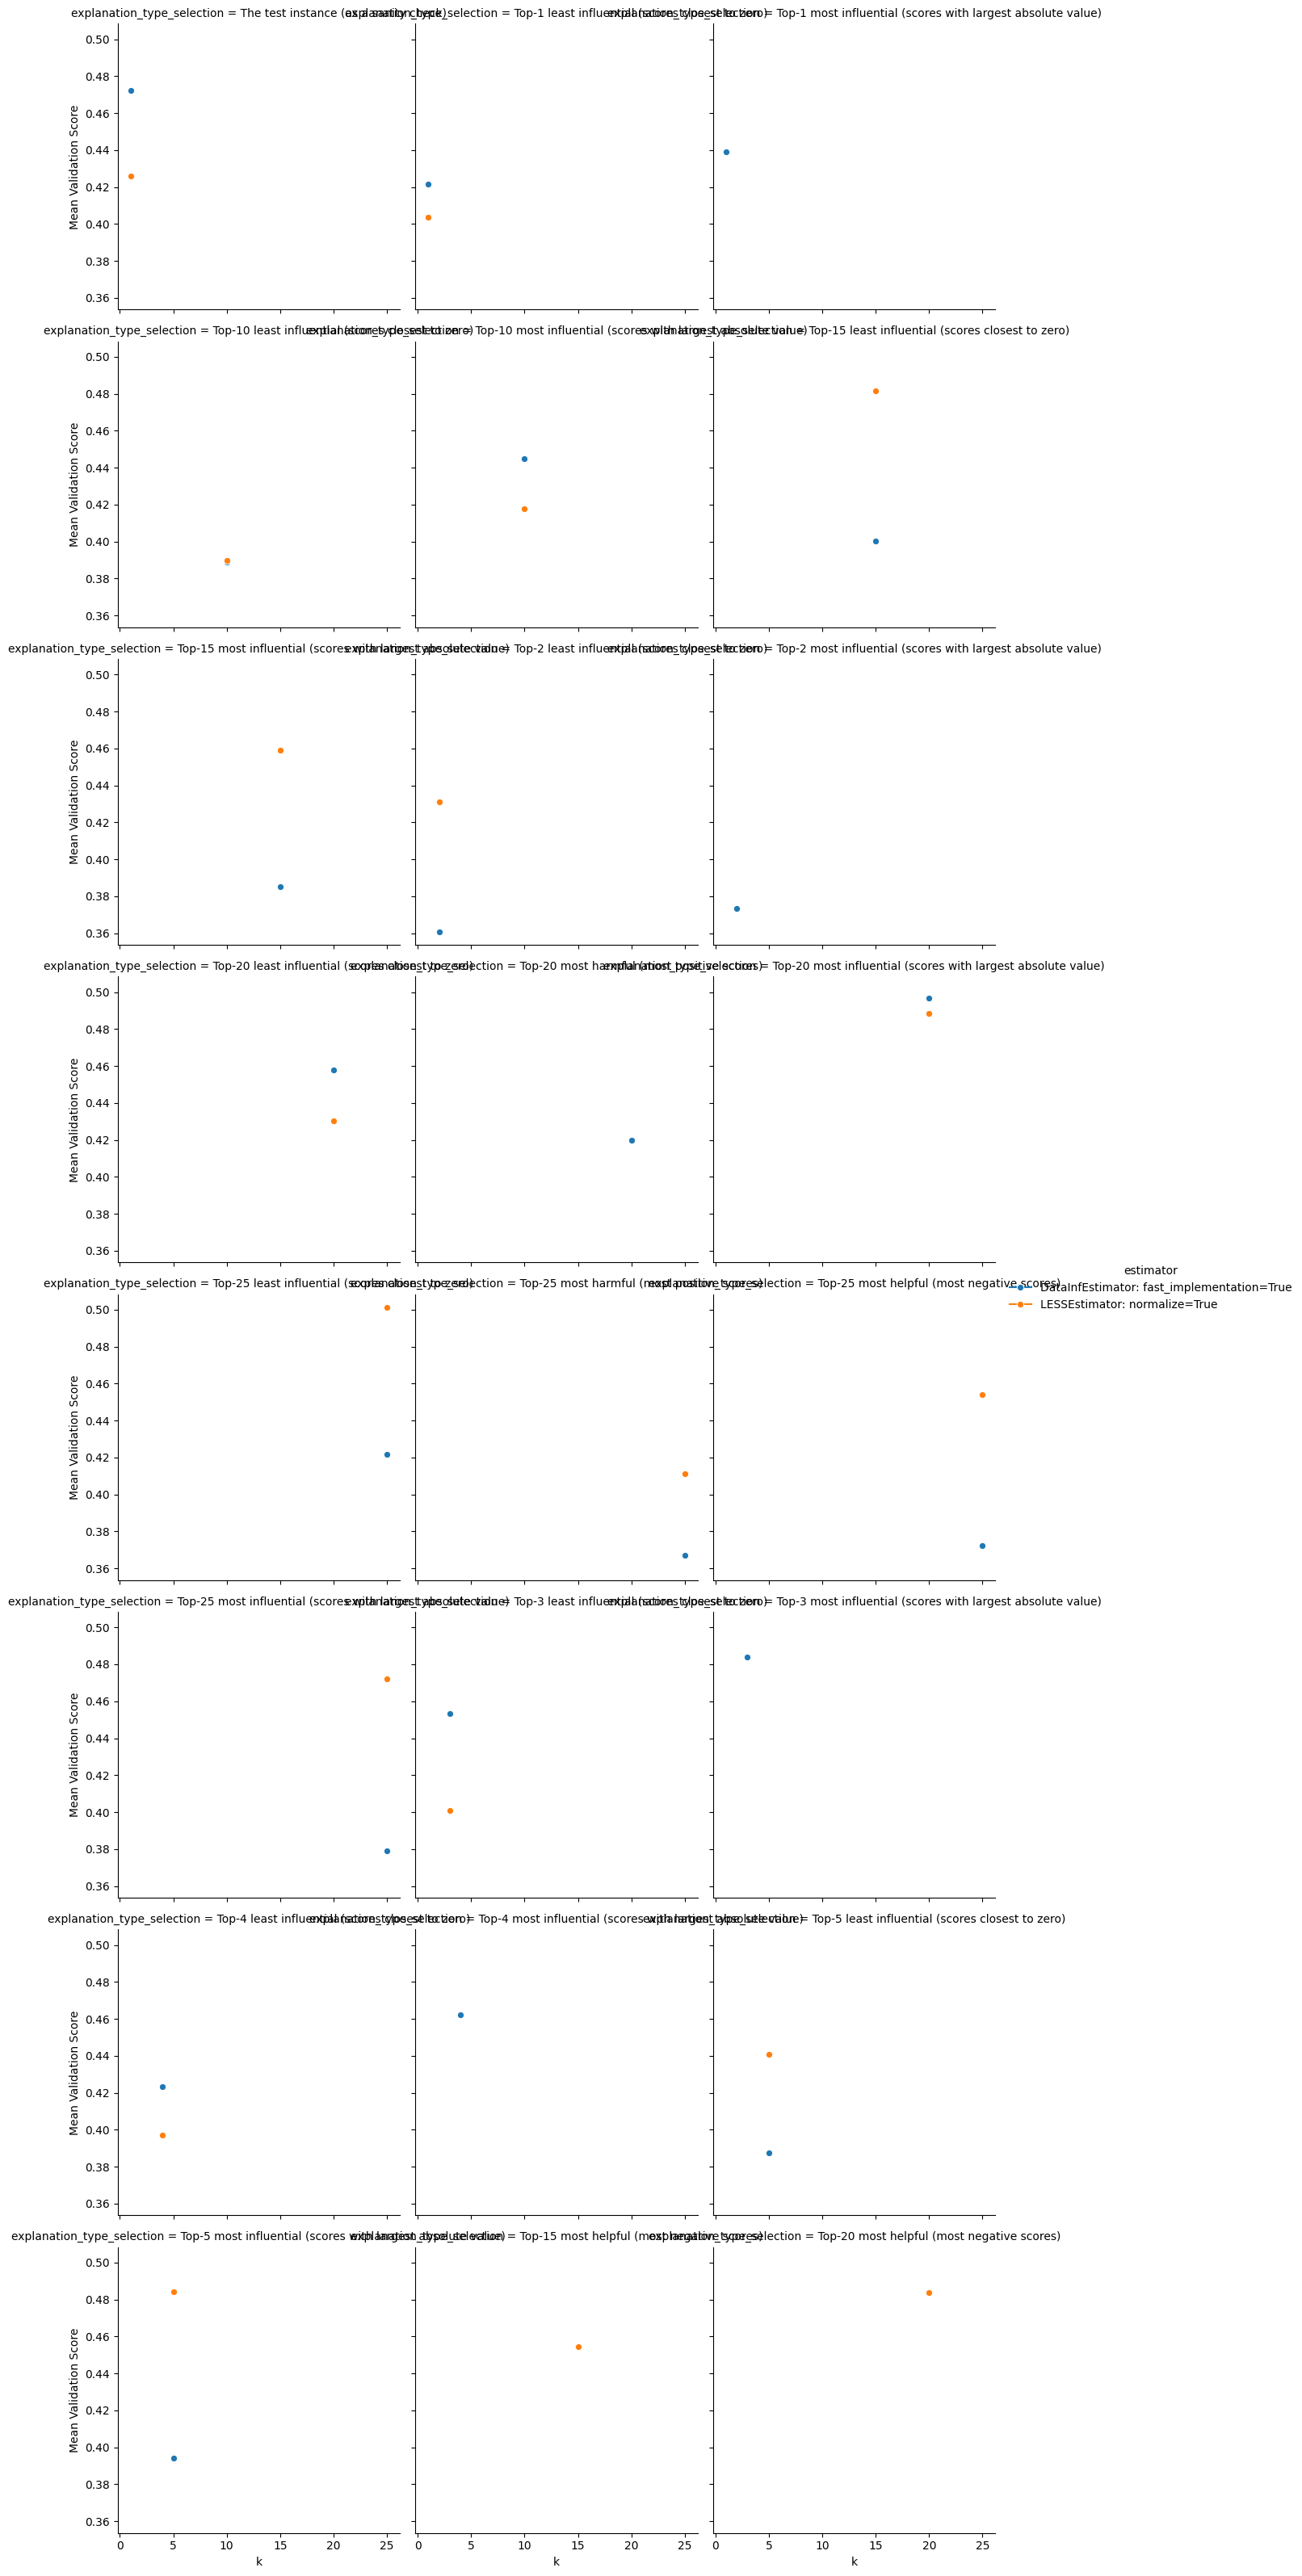

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate only over other dimensions, keeping k and explanation_type_selection
agg_df = r.groupby(
    ["estimator", "explanation_type_no_k", "k"]
).agg(
    mean_validation_score=("validation_score", "mean"),
    count_validation_score=("validation_score", "count")
).reset_index()

# Lineplot with facets for explanation_type_selection
g = sns.FacetGrid(
    agg_df, 
    col="explanation_type_no_k", 
    hue="estimator", 
    col_wrap=3,  # adjust as needed
    height=4,
    sharey=True
)
g.map(sns.lineplot, "k", "mean_validation_score", marker="o")
g.add_legend()
g.set_axis_labels("k", "Mean Validation Score")
plt.show()


In [ ]:
assert df_validation_random["explanation_type"].nunique() == (len(explanation_k) * (len(explanation_seed)))

In [ ]:
df_validation_selections["explanation_type"].nunique()

24

In [ ]:
df_validation_selections["explanation_type"].unique()

array(['The test instance (as a sanity check)',
       'Top-25 least influential (scores closest to zero)',
       'Top-1 least influential (scores closest to zero)',
       'Top-1 most influential (scores with largest absolute value)',
       'Top-10 least influential (scores closest to zero)',
       'Top-10 most influential (scores with largest absolute value)',
       'Top-15 least influential (scores closest to zero)',
       'Top-15 most influential (scores with largest absolute value)',
       'Top-2 least influential (scores closest to zero)',
       'Top-2 most influential (scores with largest absolute value)',
       'Top-20 least influential (scores closest to zero)',
       'Top-20 most harmful (most positive scores)',
       'Top-20 most influential (scores with largest absolute value)',
       'Top-25 most harmful (most positive scores)',
       'Top-25 most helpful (most negative scores)',
       'Top-25 most influential (scores with largest absolute value)',
       'Top

In [ ]:
(len(explanation_k) * (len(explanation_types)))+1

37

In [ ]:
explanation_k

[25, 20, 15, 10, 5, 4, 3, 2, 1]

In [ ]:
df_validation_random["explanation_type"].unique()

array(['25 random examples with seed 10',
       '25 random examples with seed 3',
       '25 random examples with seed 42',
       '1 random examples with seed 10', '1 random examples with seed 3',
       '1 random examples with seed 42',
       '10 random examples with seed 10',
       '10 random examples with seed 3',
       '10 random examples with seed 42',
       '10 random examples with seed 6',
       '15 random examples with seed 10',
       '15 random examples with seed 3',
       '15 random examples with seed 42',
       '15 random examples with seed 6', '15 random examples with seed 9',
       '2 random examples with seed 10', '2 random examples with seed 3',
       '2 random examples with seed 42',
       '20 random examples with seed 10',
       '20 random examples with seed 3',
       '20 random examples with seed 42',
       '20 random examples with seed 6', '20 random examples with seed 9',
       '25 random examples with seed 6', '25 random examples with seed 9',
    

In [ ]:
ghifjo0dvo

NameError: name 'ghifjo0dvo' is not defined

In [ ]:
df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random")]
# df_validation_random = df_validation_random.drop(columns=["indices_trained_on"])
df_validation_selections = df_validation[~df_validation["explanation_type"].str.contains("random")]
df_validation_selections = df_validation_selections.drop(columns=["indices_trained_on"])




In [ ]:
# df_scoring_random = df_scoring[df_scoring["explanation_type"].str.contains("random")]
# # df_scoring_random = df_scoring_random.drop(columns=["indices_trained_on"])
# df_scoring_selections = df_scoring[~df_scoring["explanation_type"].str.contains("random")]
# # df_scoring_selections = df_scoring_selections.drop(columns=["indices_trained_on"])

In [ ]:
# df_scoring_random[df_scoring_random["explanation_type"] == "1 random examples with seed 42"]["mse"].mean()

In [ ]:
df_validation_selections.groupby("explanation_type").count()

,model,estimator,document_idx,train_dataset,train_split,test_dataset,test_split,indices_target_document,delta_target_document
explanation_type,,,,,,,,,
The test instance (as a sanity check),2367,2367,2367,2367,2367,2367,2367,2367,2367
Top-1 least influential (scores closest to zero),2000,2000,2000,2000,2000,2000,2000,2000,2000
Top-1 most influential (scores with largest absolute value),1000,1000,1000,1000,1000,1000,1000,1000,1000
Top-10 least influential (scores closest to zero),2000,2000,2000,2000,2000,2000,2000,2000,2000
Top-10 most influential (scores with largest absolute value),2000,2000,2000,2000,2000,2000,2000,2000,2000
Top-15 least influential (scores closest to zero),2000,2000,2000,2000,2000,2000,2000,2000,2000
Top-15 most helpful (most negative scores),602,602,602,602,602,602,602,602,602
Top-15 most influential (scores with largest absolute value),2000,2000,2000,2000,2000,2000,2000,2000,2000
Top-2 least influential (scores closest to zero),2000,2000,2000,2000,2000,2000,2000,2000,2000


In [ ]:
df_validation_selections.groupby("explanation_type").nunique()

,model,estimator,document_idx,train_dataset,train_split,test_dataset,test_split,indices_target_document,delta_target_document
explanation_type,,,,,,,,,
The test instance (as a sanity check),2,2,1000,1,1,1,1,1000,2366
Top-1 least influential (scores closest to zero),1,2,1000,1,1,1,1,1000,2000
Top-1 most influential (scores with largest absolute value),1,1,1000,1,1,1,1,1000,1000
Top-10 least influential (scores closest to zero),1,2,1000,1,1,1,1,1000,2000
Top-10 most influential (scores with largest absolute value),1,2,1000,1,1,1,1,1000,2000
Top-15 least influential (scores closest to zero),1,2,1000,1,1,1,1,1000,1999
Top-15 most helpful (most negative scores),1,1,602,1,1,1,1,602,602
Top-15 most influential (scores with largest absolute value),1,2,1000,1,1,1,1,1000,2000
Top-2 least influential (scores closest to zero),1,2,1000,1,1,1,1,1000,2000


In [ ]:
df_validation_random = df_validation_random.drop(columns=["indices_trained_on"])
df_validation_random

,explanation_type,model,estimator,document_idx,train_dataset,train_split,test_dataset,test_split,indices_target_document,delta_target_document
0,25 random examples with seed 10,Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,0,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,0,14.734511
1,25 random examples with seed 10,Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,100,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,100,-1.273284
2,25 random examples with seed 10,Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,1,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,1,0.305113
3,25 random examples with seed 10,Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,10,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,10,-0.498101
4,25 random examples with seed 10,Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr...,DataInfEstimator: fast_implementation=True,101,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,101,6.012773
...,...,...,...,...,...,...,...,...,...,...
99558,5 random examples with seed 9,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,995,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,995,-15.340376
99559,5 random examples with seed 9,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,996,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,996,-12.004891
99560,5 random examples with seed 9,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,997,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,997,-23.289436
99561,5 random examples with seed 9,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,LESSEstimator: normalize=True,998,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,998,-12.062170


In [ ]:
import re
import pandas as pd

pattern = r"Top-(\d+)"
group_cols = [
    "model",
    "estimator",
    "train_dataset",
    "train_split",
    "test_dataset",
    "test_split",
    # "LESSEstimator: normalize",
    "document_idx"
]

results = []
for linear_coder in linear_coders:
    linear_coder = linear_coder.__name__
    for explanation_type in df_validation_selections["explanation_type"].unique():
        k = int(re.match(pattern, explanation_type).group(1)) if "The test instance (as a sanity check)" not in explanation_type else 1

        # Only random runs matching this k
        random_run_names = df_validation_random[
            df_validation_random["explanation_type"].str.contains(f"{k} random")
        ]["explanation_type"].unique()

        for random_run_name in random_run_names:

            # Filter and drop duplicate rows per document
            sel = df_validation_selections[(df_validation_selections["explanation_type"] == explanation_type)]
            rnd = df_validation_random[(df_validation_random["explanation_type"] == random_run_name)]
            scores_sel = df_scoring_selections[(df_scoring_selections["explanation_type"] == explanation_type) & (df_scoring_selections["linear_coder"] == linear_coder)]
            scores_rnd = df_scoring_random[(df_scoring_random["explanation_type"] == random_run_name) &(df_scoring_random["linear_coder"] == linear_coder)]

            # Merge selection and random results on group_cols
            r = pd.merge(
                sel,
                rnd,
                on=group_cols,
                suffixes=("_selection", "_random"),
                how="inner"
            )

            # Merge pred_gain columns
            r = pd.merge(
                r,
                scores_sel[group_cols + ["pred_gain", "mse"]].rename(columns={"pred_gain": "pred_gain_selection","mse": "mse_selection"}),
                on=group_cols,
                how="left"
            )
            r = pd.merge(
                r,
                scores_rnd[group_cols + ["pred_gain","mse"]].rename(columns={"pred_gain": "pred_gain_random", "mse": "mse_random"}),
                on=group_cols,
                how="left"
            )



            if len(r) == 0:
                continue
            # display(r[[col for col in r.columns if col != 'indices_trained_on']].nunique())
            # display(r[[col for col in r.columns if col != 'indices_trained_on']].count())
            # display(len(scores_sel))
            # display(scores_sel[group_cols + ["pred_gain", "mse"]].rename(columns={"pred_gain": "pred_gain_selection","mse": "mse_selection"}).count())
            # raise Error

            # Compute summary statistics per random run
            results.append({
                "linear_coder": linear_coder,
                "explanation_type": explanation_type,
                "random_run": random_run_name,
                "k": k,
                "validation_score": (r["delta_target_document_selection"] >= r["delta_target_document_random"]).mean(skipna=True),
                "pred_gain_selection": r["pred_gain_selection"].mean(skipna=True),
                "pred_gain_random": r["pred_gain_random"].mean(skipna=True),
                "mse_selection": r["mse_selection"].mean(skipna=True),
                "mse_random": r["mse_random"].mean(skipna=True),
                "count": len(r),
                **r.iloc[0][[col for col in group_cols if col != "document_idx"]].to_dict(),
            })
            


results_df = pd.DataFrame(results)
results_df


39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 78408 39095
39095 7840

39095 78408 39095
39095 78408 39095


KeyboardInterrupt: 

In [ ]:
results_df.groupby(["linear_coder", "explanation_type","model","estimator"]).mean(numeric_only=True)

k  \
linear_coder                      explanation_type                                   model                                              estimator                                          
KLTCoder                          The test instance (as a sanity check)              Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr1... DataInfEstimator: fast_implementation=True   1.0   
                                  Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True   1.0   
                                  Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True   1.0   
                                  Top-10 least influential (scores closest to zero)  OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True  10.0   
                                  Top-10 most influential (scores with largest ab... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True  10.0   
...                                                                                                                                                                                  ...   
MSECoderProjUSimpSparseSoftThresh Top-3 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True   3.0   
                                  Top-4 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True   4.0   
                                  Top-4 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True   4.0   
                                  Top-5 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True   5.0   
                                  Top-5 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True   5.0   

                                                                                                                                                                                    validation_score  \
linear_coder                      explanation_type                                   model                                              estimator                                                      
KLTCoder                          The test instance (as a sanity check)              Llama-3.2-1B_tulu-3-sft-olmo-2-mixture-0225_lr1... DataInfEstimator: fast_implementation=True          0.283735   
                                  Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True          0.310400   
                                  Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True          0.263400   
                                  Top-10 least influential (scores closest to zero)  OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True          0.350400   
                                  Top-10 most influential (scores with largest ab... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... DataInfEstimator: fast_implementation=True          0.386900   
...                                                                                                                                                                                              ...   
MSECoderProjUSimpSparseSoftThresh Top-3 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... Da

In [ ]:
from scipy.stats import ttest_rel

results = []

for (k, exp_type,linear_coder), group in results_df.groupby(['k', 'explanation_type', 'linear_coder']):
    # paired test: selection vs random
    t_stat, p_value = ttest_rel(group['validation_score'], group['pred_gain_random'], alternative='greater')
    results.append({'k': k,"linear_coder":linear_coder, 'explanation_type': exp_type, 't_stat': t_stat, 'p_value': p_value})

pd.DataFrame(results)



,k,linear_coder,explanation_type,t_stat,p_value
0,1,KLTCoder,The test instance (as a sanity check),-8.763484,0.999533
1,1,MSECoder,The test instance (as a sanity check),-9.042124,0.999586
2,1,MSECoderNNLSL2,The test instance (as a sanity check),-9.042128,0.999586
3,1,MSECoderProjUSimp,The test instance (as a sanity check),-4.815039,0.995723
4,1,MSECoderProjUSimpSparse,The test instance (as a sanity check),-4.815039,0.995723
5,1,MSECoderProjUSimpSparseSoftThresh,The test instance (as a sanity check),-4.815039,0.995723
6,5,KLTCoder,Top-5 least influential (scores closest to zero),-11.620142,1.000000
7,5,MSECoder,Top-5 least influential (scores closest to zero),-24.207694,1.000000
8,5,MSECoderNNLSL2,Top-5 least influential (scores closest to zero),-17.965425,1.000000
9,5,MSECoderProjUSimp,Top-5 least influential (scores closest to zero),-21.674317,1.000000


In [ ]:
from scipy.stats import wilcoxon
w_stat, p_value = wilcoxon(group['validation_score'], group['pred_gain_random'], alternative='greater')
w_stat

0.0

In [ ]:
p_value

1.0

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Drop NaNs
df = results_df.dropna(subset=["validation_score", "pred_gain_selection", "pred_gain_random"])

# Mixed-effects model
# 'random_run' is a grouping variable (random intercept)
# You can optionally include 'explanation_type' as another random effect
md = smf.mixedlm(
    "validation_score ~ pred_gain_selection + pred_gain_random",
    df,
    groups=df["random_run"]
)
mdf = md.fit()
print(mdf.summary())


            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: validation_score
No. Observations: 282     Method:             REML            
No. Groups:       23      Scale:              0.0011          
Min. group size:  6       Log-Likelihood:     500.3297        
Max. group size:  24      Converged:          Yes             
Mean group size:  12.3                                        
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.437    0.028 15.567 0.000  0.382  0.493
pred_gain_selection  0.008    0.009  0.933 0.351 -0.009  0.026
pred_gain_random    -0.003    0.007 -0.430 0.667 -0.017  0.011
Group Var            0.014    0.137                           



In [ ]:
corr_selection = results_df['validation_score'].corr(results_df['pred_gain_selection'])
corr_random = results_df['validation_score'].corr(results_df['pred_gain_random'])

print(f"Correlation with pred_gain_selection: {corr_selection:.3f}")
print(f"Correlation with pred_gain_random: {corr_random:.3f}")


Correlation with pred_gain_selection: -0.009
Correlation with pred_gain_random: 0.088


In [ ]:
import statsmodels.api as sm

# Validation score ~ pred_gain_selection
X1 = sm.add_constant(results_df['pred_gain_selection'])
model1 = sm.OLS(results_df['validation_score'], X1).fit()
print(model1.summary())

# Validation score ~ pred_gain_random
X2 = sm.add_constant(results_df['pred_gain_random'])
model2 = sm.OLS(results_df['validation_score'], X2).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:       validation_score   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                   0.02210
Date:                Sat, 27 Sep 2025   Prob (F-statistic):              0.882
Time:                        09:16:21   Log-Likelihood:                 190.28
No. Observations:                 282   AIC:                            -376.6
Df Residuals:                     280   BIC:                            -369.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4569    

In [ ]:
import statsmodels.api as sm
import pandas as pd

results = []

for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = -pd.to_numeric(group["mse"], errors="coerce")  # negate MSE so lower is better
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(pd.DataFrame({"neg_mse": x_clean}))
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("neg_mse", None),       
        "p_value": model.pvalues.get("neg_mse", None),  
        "r_squared": model.rsquared
    })

results_df = pd.DataFrame(results)
results_df


KeyError: 'mse'

In [ ]:
import statsmodels.api as sm

results = []


for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = pd.to_numeric(group["pred_gain"], errors="coerce")
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(x_clean)
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("pred_gain", None),
        "p_value": model.pvalues.get("pred_gain", None),
        "r_squared": model.rsquared
    })


results_df = pd.DataFrame(results)
results_df
